# ⚙️ 그래프 기반 검색 알고리즘 (NSW) 기초 시뮬레이션

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(42)

## 1. 2D 무작위 노드 맵 생성
이해를 돕기 위해 768차원이 아닌 2차원 공간에 1,000개의 점(문서)을 찍어 가상의 데이터베이스를 만듭니다.

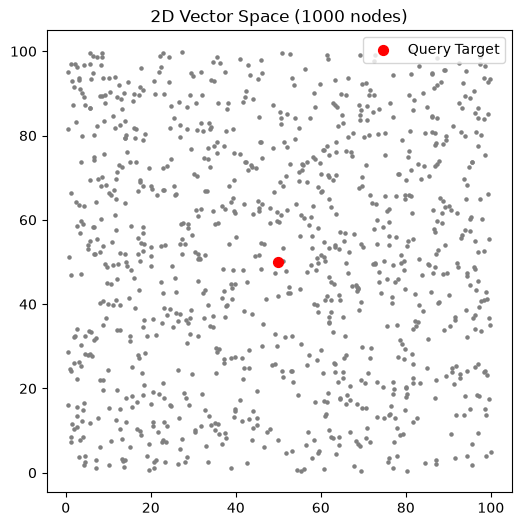

In [2]:
num_nodes = 1000
nodes = np.random.rand(num_nodes, 2) * 100

query = np.array([50.0, 50.0]) # 중앙 부근의 타겟 좌표

plt.figure(figsize=(6,6))
plt.scatter(nodes[:, 0], nodes[:, 1], s=5, color='gray')
plt.scatter(query[0], query[1], s=50, color='red', label='Query Target')
plt.legend()
plt.title("2D Vector Space (1000 nodes)")
plt.show()

## 2. Brute-force KNN (전수 조사)
모든 1,000개의 점과 거리를 일일이 계산하여 가장 가까운 점을 찾습니다.

In [3]:
def brute_force_search(query, nodes):
    # 유클리디안 거리 전체 계산
    distances = np.linalg.norm(nodes - query, axis=1)
    nearest_idx = np.argmin(distances)
    return nearest_idx, distances[nearest_idx]

start_time = time.perf_counter()
best_idx, best_dist = brute_force_search(query, nodes)
knn_time = time.perf_counter() - start_time

print(f"KNN 찾은 정답 노드: {best_idx} (거리: {best_dist:.4f})")
print(f"탐색에 걸린 시간: {knn_time:.6f} 초")
print("연산 횟수: 1000 번")

KNN 찾은 정답 노드: 137 (거리: 1.1443)
탐색에 걸린 시간: 0.000532 초
연산 횟수: 1000 번


## 3. Basic NSW (Navigable Small World) 그리디 탐색 시뮬레이션
전수 조사를 피하기 위해, 임의의 진입점(Entry)에서 시작하여 '주변에 있는 이웃 중 타겟과 더 가까운 곳'으로만 점프하는 로직을 시뮬레이션합니다. (그래프 엣지 구축은 간소화)

In [4]:
# 시뮬레이션을 위한 가상의 이웃 검색 함수 (실제 HNSW는 인덱싱 단계에서 이웃 리스트를 미리 저장함)
def get_neighbors(node_idx, k=15):
    # 자기 주변의 가까운 이웃 15개를 가져온다고 가정
    dist = np.linalg.norm(nodes - nodes[node_idx], axis=1)
    # 거리순 정렬 후 최상위 15개 리턴 (자신 제외 1번 인덱스부터)
    return np.argsort(dist)[1:k+1]

def greedy_graph_search(query, start_node_idx):
    current_node = start_node_idx
    current_dist = np.linalg.norm(nodes[current_node] - query)
    
    steps = 0
    path = [current_node]
    
    while True:
        steps += 1
        neighbors = get_neighbors(current_node)
        
        # 이웃들 중 쿼리와의 거리 계산
        neighbor_dists = np.linalg.norm(nodes[neighbors] - query, axis=1)
        best_neighbor_idx = np.argmin(neighbor_dists)
        best_neighbor_dist = neighbor_dists[best_neighbor_idx]
        
        # 만약 이웃 중에 지금 내 위치보다 타겟에 더 가까운 녀석이 있다면 점프!
        if best_neighbor_dist < current_dist:
            current_node = neighbors[best_neighbor_idx]
            current_dist = best_neighbor_dist
            path.append(current_node)
        else:
            # 이웃을 다 둘러봐도 지금 위치가 제일 가깝다면 탐색 종료 (Local Minimum 도달)
            break
            
    return current_node, current_dist, steps, path

# 아무 구석이나 진입점으로 설정
entry_node = 0 
start_time = time.perf_counter()
res_idx, res_dist, steps, path = greedy_graph_search(query, entry_node)
nsw_time = time.perf_counter() - start_time

print(f"NSW 찾은 노드: {res_idx} (거리: {res_dist:.4f})")
print(f"탐색에 걸린 시간: {nsw_time:.6f} 초")
print(f"도약(점프) 횟수: {steps} 번 (전수 조사 1000번 대비 극단적 감소!)")

print("\n💡 결론: 모든 데이터를 검사하지 않고도, 그래프의 연결망을 타면서 타겟 근처로 매우 빠르게 수렴(Routing)하는 ANN의 강력함을 볼 수 있습니다.")

NSW 찾은 노드: 137 (거리: 1.1443)
탐색에 걸린 시간: 0.003972 초
도약(점프) 횟수: 10 번 (전수 조사 1000번 대비 극단적 감소!)

💡 결론: 모든 데이터를 검사하지 않고도, 그래프의 연결망을 타면서 타겟 근처로 매우 빠르게 수렴(Routing)하는 ANN의 강력함을 볼 수 있습니다.
